In [1]:
!pip install datasets pandas matplotlib scikit-learn numpy -q

In [2]:
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
ds = load_dataset("korkmazemin1/turkish-education-dataset", split="train")
df = pd.DataFrame(ds)

print("Satır sayısı:", len(df))
print("Sütunlar:", df.columns.tolist())

df.head()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

turkish_education_dataset.parquet:   0%|          | 0.00/12.6M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/17587 [00:00<?, ? examples/s]

Satır sayısı: 17587
Sütunlar: ['soru', 'cevap', 'veri türü', 'kaynak', 'context', 'Score']


,soru,cevap,veri türü,kaynak,context,Score
0,Doğal sistemler birbirleriyle nasıl etkileşim ...,Doğal sistemler birbirleriyle karmaşık bir şek...,egitim,OGM Konu Ozetleri,"DOĞA VE İNSAN ETKİLEŞİMİ\r\nDoğa, başta insan ...",8
1,Doğal çevrenin farklı bölgelerinde yaşayan ins...,Doğal çevrenin farklı bölgelerinde yaşayan ins...,egitim,OGM Konu Ozetleri,"DOĞA VE İNSAN ETKİLEŞİMİ\r\nDoğa, başta insan ...",8
2,İnsanlar doğal çevreye nasıl uyum sağlayarak f...,"İnsanlar, doğal çevreye uyum sağlayarak farklı...",egitim,OGM Konu Ozetleri,"DOĞA VE İNSAN ETKİLEŞİMİ\r\nDoğa, başta insan ...",8
3,Doğal çevrenin insan kültürüne etkisi nedir?,"Doğal çevre, insan kültürünü derinlemesine etk...",egitim,OGM Konu Ozetleri,"DOĞA VE İNSAN ETKİLEŞİMİ\r\nDoğa, başta insan ...",8
4,Doğal çevrenin insan sağlığı üzerindeki etkile...,"Doğal çevre, insan sağlığı üzerinde hem olumlu...",egitim,OGM Konu Ozetleri,"DOĞA VE İNSAN ETKİLEŞİMİ\r\nDoğa, başta insan ...",8


In [4]:
score_counts = df["Score"].value_counts().sort_index()

print(score_counts)

Score
-2     3118
 0        7
 1        7
 2       25
 3       16
 4       21
 5       20
 6      147
 7      879
 8     7734
 9     5047
 10     566
Name: count, dtype: int64


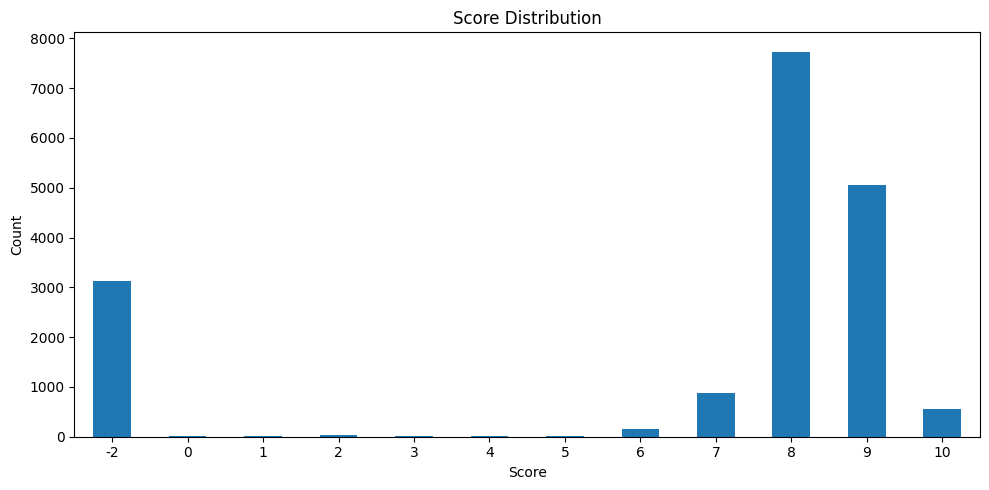

In [5]:
plt.figure(figsize=(10, 5))
score_counts.plot(kind="bar")

plt.title("Score Distribution")
plt.xlabel("Score")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [6]:
# Score = -2: Not Scored olduğu için çıkarılır
# Score = -1: Safety kategorisi varsa çıkarılır, bu veri setinde görünmüyor ama kontrol için ekliyoruz

df_clean = df[~df["Score"].isin([-2, -1])].copy()

print("Orijinal satır sayısı:", len(df))
print("Temizlenmiş satır sayısı:", len(df_clean))
print("Çıkarılan satır sayısı:", len(df) - len(df_clean))

print("\nTemizlenmiş Score dağılımı:")
print(df_clean["Score"].value_counts().sort_index())

Orijinal satır sayısı: 17587
Temizlenmiş satır sayısı: 14469
Çıkarılan satır sayısı: 3118

Temizlenmiş Score dağılımı:
Score
0        7
1        7
2       25
3       16
4       21
5       20
6      147
7      879
8     7734
9     5047
10     566
Name: count, dtype: int64


In [7]:
# Strategy A:
# Score <= 7  -> düşük kalite (0)
# Score >= 8  -> yüksek kalite (1)

df_strategy_a = df_clean.copy()
df_strategy_a["label"] = df_strategy_a["Score"].apply(lambda x: 0 if x <= 7 else 1)

print("Strategy A label dağılımı:")
print(df_strategy_a["label"].value_counts().sort_index())
print("\nStrategy A yüzde dağılımı:")
print(df_strategy_a["label"].value_counts(normalize=True).sort_index() * 100)

Strategy A label dağılımı:
label
0     1122
1    13347
Name: count, dtype: int64

Strategy A yüzde dağılımı:
label
0     7.75451
1    92.24549
Name: proportion, dtype: float64


In [8]:
# Strategy B:
# Score <= 8  -> düşük kalite (0)
# Score >= 9  -> yüksek kalite (1)

df_strategy_b = df_clean.copy()
df_strategy_b["label"] = df_strategy_b["Score"].apply(lambda x: 0 if x <= 8 else 1)

print("Strategy B label dağılımı:")
print(df_strategy_b["label"].value_counts().sort_index())
print("\nStrategy B yüzde dağılımı:")
print(df_strategy_b["label"].value_counts(normalize=True).sort_index() * 100)

Strategy B label dağılımı:
label
0    8856
1    5613
Name: count, dtype: int64

Strategy B yüzde dağılımı:
label
0    61.206718
1    38.793282
Name: proportion, dtype: float64


In [9]:
label_summary = pd.DataFrame({
    "strategy": ["A_score_7_8", "A_score_7_8", "B_score_8_9", "B_score_8_9"],
    "label": [0, 1, 0, 1],
    "meaning": [
        "low_quality_score_<=7",
        "high_quality_score_>=8",
        "low_quality_score_<=8",
        "high_quality_score_>=9"
    ],
    "count": [
        df_strategy_a["label"].value_counts().sort_index().loc[0],
        df_strategy_a["label"].value_counts().sort_index().loc[1],
        df_strategy_b["label"].value_counts().sort_index().loc[0],
        df_strategy_b["label"].value_counts().sort_index().loc[1],
    ],
    "percentage": [
        df_strategy_a["label"].value_counts(normalize=True).sort_index().loc[0] * 100,
        df_strategy_a["label"].value_counts(normalize=True).sort_index().loc[1] * 100,
        df_strategy_b["label"].value_counts(normalize=True).sort_index().loc[0] * 100,
        df_strategy_b["label"].value_counts(normalize=True).sort_index().loc[1] * 100,
    ]
})

label_summary

,strategy,label,meaning,count,percentage
0,A_score_7_8,0,low_quality_score_<=7,1122,7.754510
1,A_score_7_8,1,high_quality_score_>=8,13347,92.245490
2,B_score_8_9,0,low_quality_score_<=8,8856,61.206718
3,B_score_8_9,1,high_quality_score_>=9,5613,38.793282


In [10]:
from sklearn.model_selection import train_test_split

In [11]:
def create_splits(df_labeled, label_col="label", seed=42):
    # Önce %80 train, %20 temp ayırıyoruz
    train_df, temp_df = train_test_split(
        df_labeled,
        test_size=0.20,
        random_state=seed,
        stratify=df_labeled[label_col]
    )

    # Temp'in yarısı validation, yarısı test olacak: %10 / %10
    val_df, test_df = train_test_split(
        temp_df,
        test_size=0.50,
        random_state=seed,
        stratify=temp_df[label_col]
    )

    return train_df, val_df, test_df

In [12]:
a_train, a_val, a_test = create_splits(df_strategy_a)
b_train, b_val, b_test = create_splits(df_strategy_b)

print("Strategy A:")
print("Train:", len(a_train), "Validation:", len(a_val), "Test:", len(a_test))

print("\nStrategy B:")
print("Train:", len(b_train), "Validation:", len(b_val), "Test:", len(b_test))

Strategy A:
Train: 11575 Validation: 1447 Test: 1447

Strategy B:
Train: 11575 Validation: 1447 Test: 1447


In [13]:
def split_label_distribution(name, train_df, val_df, test_df):
    for split_name, split_df in [
        ("train", train_df),
        ("validation", val_df),
        ("test", test_df)
    ]:
        counts = split_df["label"].value_counts().sort_index()
        percents = split_df["label"].value_counts(normalize=True).sort_index() * 100

        print(f"\n{name} - {split_name}")
        print(pd.DataFrame({
            "count": counts,
            "percentage": percents.round(2)
        }))

split_label_distribution("Strategy A", a_train, a_val, a_test)
split_label_distribution("Strategy B", b_train, b_val, b_test)


Strategy A - train
       count  percentage
label                   
0        898        7.76
1      10677       92.24

Strategy A - validation
       count  percentage
label                   
0        112        7.74
1       1335       92.26

Strategy A - test
       count  percentage
label                   
0        112        7.74
1       1335       92.26

Strategy B - train
       count  percentage
label                   
0       7085       61.21
1       4490       38.79

Strategy B - validation
       count  percentage
label                   
0        886       61.23
1        561       38.77

Strategy B - test
       count  percentage
label                   
0        885       61.16
1        562       38.84


In [14]:
import os

os.makedirs("data/splits/strategy_a", exist_ok=True)
os.makedirs("data/splits/strategy_b", exist_ok=True)
os.makedirs("outputs/tables", exist_ok=True)

# Strategy A splits
a_train.to_csv("data/splits/strategy_a/train.csv", index=False)
a_val.to_csv("data/splits/strategy_a/validation.csv", index=False)
a_test.to_csv("data/splits/strategy_a/test.csv", index=False)

# Strategy B splits
b_train.to_csv("data/splits/strategy_b/train.csv", index=False)
b_val.to_csv("data/splits/strategy_b/validation.csv", index=False)
b_test.to_csv("data/splits/strategy_b/test.csv", index=False)

# Label summary
label_summary.to_csv("outputs/tables/label_strategy_summary.csv", index=False)

print("Dosyalar kaydedildi.")

Dosyalar kaydedildi.


In [15]:
for path in [
    "data/splits/strategy_a/train.csv",
    "data/splits/strategy_a/validation.csv",
    "data/splits/strategy_a/test.csv",
    "data/splits/strategy_b/train.csv",
    "data/splits/strategy_b/validation.csv",
    "data/splits/strategy_b/test.csv",
    "outputs/tables/label_strategy_summary.csv"
]:
    print(path, "->", os.path.exists(path))

data/splits/strategy_a/train.csv -> True
data/splits/strategy_a/validation.csv -> True
data/splits/strategy_a/test.csv -> True
data/splits/strategy_b/train.csv -> True
data/splits/strategy_b/validation.csv -> True
data/splits/strategy_b/test.csv -> True
outputs/tables/label_strategy_summary.csv -> True
